In [1]:
import pandas as pd

In [2]:
# считываю данные без внутренней индексации pandas, так как для этого уже есть столбец
train_data = pd.read_excel('Training.xlsx', index_col='ID')
test_data = pd.read_excel('Test.xlsx', index_col='ID')

In [3]:
# определение задачи + отделение таргета от датасета
x_train, y_train = train_data.drop(columns=['MARKER']), train_data['MARKER']
x_test, y_test = test_data.drop(columns=['MARKER']), test_data['MARKER']
print(f'Тип данных целевой переменной: {y_train.dtype}\nМножество возможных значений: {y_train.unique()}')

Тип данных целевой переменной: int64
Множество возможных значений: [0 1]


Целевой переменной является признак MARKER, принимающий значения 0 и 1. Следовательно, задача представляет собой задачу бинарной классификации.

# EDA

In [4]:
x_train.head()

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
ID,,,,,,,,,,,,,,,,,,,,,
1,0.198778,0.099389,0.00,799.90,1.777556,0.888778,13,3.49,woman,33.750000,...,property,No,Works,Yes,Yes,No,Yes,No,3.393876,2.432165
2,0.043000,0.021264,49.97,173.03,NaN,0.190143,13,3.49,Woman,33.250000,...,otherwise,No,Works,Yes,Yes,Yes,Yes,No,-0.517659,1.209422
3,0.067073,0.067073,0.00,329.90,0.599818,0.599818,13,3.49,Woman,38.583333,...,property,No,No couple,No,Yes,No,Yes,No,4.645817,1.821789
4,0.052700,0.052700,0.00,235.65,0.471300,0.471300,13,3.49,Woman,61.250000,...,property,No,No couple,Yes,Yes,Few,Yes,No,-3.055776,1.602076
5,0.141880,0.141880,0.00,634.45,1.268900,1.268900,13,3.49,Woman,48.583333,...,property,No,No couple,Yes,No,No,No,No,-3.474083,3.556995


In [5]:
print(f'Размерность тренировочного датасета: {x_train.shape}')
print(f'Размерность тестирующего датасета: {x_test.shape}')

Размерность тренировочного датасета: (91528, 26)
Размерность тестирующего датасета: (38405, 26)


Обучающая выборка содержит 91 528 наблюдений, тестовая - 38 405 наблюдений. Размер выборки достаточен для применения как линейных моделей, так и ансамблевых методов.

In [6]:
# распределение целевой переменной
y_train.value_counts(normalize=True)

MARKER
0    0.996209
1    0.003791
Name: proportion, dtype: float64

Наблюдается очень сильный дисбаланс классов. Доля клиентов с дефолтом составляет около 0.38%, тогда как доля клиентов без дефолта превышает 99%.

В связи с этим полагаться на метрику Accuracy нецелесообразно, поскольку можно взять модель, предсказывающую всегда отсутствие дефолта для всех клиентов, и она будет демонстрировать очень высокую точность при отсутствии какой-либо реальной пользы.
При построении моделей особое внимание следует уделить метрикам, учитывающим дисбаланс классов.

In [7]:
all_types = train_data.dtypes.unique().astype(str).tolist()
categorical_features = x_train.select_dtypes(include='object').columns.to_list()
numeric_features = x_train.select_dtypes(include=['float64', 'int64']).columns.to_list()
print(f'Все типы данных в датасете: {all_types}')
print(f'Все категориальные признаки({len(categorical_features)}/{x_train.shape[1]}): {categorical_features}')

Все типы данных в датасете: ['float64', 'int64', 'object']
Все категориальные признаки(14/26): ['I', 'K', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X']


В датасете всего три возможных типа данных у признаков: `float64`, `int64`, `object`. Также, как мы можем увидеть в выводе, в датасете большая часть признаков - категориальные. Это очень важно для дальнейшей работы и выбора моделей.
Что еще бросается в глаза, это то что в некоторых признаках одно и то же слово может быть написано в разных регистрах, хотя суть одна и та же. Надо изучить этот момент

In [8]:
# изучаем число уникальных значений признаков с приведением к одному регистру и без приведения
cat_unique = pd.DataFrame({'Признак': categorical_features, 'Уникальных значений(без приведения)': [x_train[col].nunique() for col in categorical_features],
                           'Уникальных значений(с приведением)': [x_train[col].str.lower().nunique() for col in categorical_features]})
display(cat_unique.style.hide())

Признак,Уникальных значений(без приведения),Уникальных значений(с приведением)
I,10,6
K,7,7
M,5,5
N,4,4
O,4,4
P,5,5
Q,3,3
R,2,2
S,5,5
T,2,2


Как видно в выводе, в признаке `I` стало меньше уникальных значений после приведения. Но в будущем нам надо будет привести ВСЕ категориальные признаки к одному регистру (например, нижнему), так как мы не можем гарантировать что на инференсе нам не смешают регистры для других признаков

In [9]:
# исследование данных на пропуски
from IPython.display import display_html

cat_null = pd.DataFrame({'Категориальный признак': categorical_features, 'Пропуски (%)': [x_train[col].isna().sum() / len(x_train) * 100 for col in categorical_features]})
num_null = pd.DataFrame({'Числовой признак': numeric_features, 'Пропуски (%)': [x_train[col].isna().sum() / len(x_train) * 100 for col in numeric_features]})

style_cat = cat_null.style.hide().set_table_attributes("style='display:inline; margin-right:40px;'").to_html()
style_num = num_null.style.hide().set_table_attributes("style='display:inline;'").to_html()

display_html(style_cat + style_num, raw=True)

Категориальный признак,Пропуски (%)
I,0.000000
K,4.185604
M,0.000000
N,0.000000
O,0.000000
P,0.000000
Q,0.000000
R,0.000000
S,4.014072
T,0.000000


In [ ]:
nan_impact_cat = {}
for col in categorical_features:
    stats = train_data.groupby(train_data[col].isna())['MARKER'].mean()
    nan_impact_cat[col] = {
        'Данные есть (False)': stats.get(False, 0),
        'Пропуск (True)': stats.get(True, 0)
    }
df_nan_impact = pd.DataFrame(nan_impact_cat).T
display(df_nan_impact.style.format('{:.4%}'))

,Данные есть (False),Пропуск (True)
I,0.3791%,0.0000%
K,0.3752%,0.4699%
M,0.3791%,0.0000%
N,0.3791%,0.0000%
O,0.3791%,0.0000%
P,0.3791%,0.0000%
Q,0.3791%,0.0000%
R,0.3791%,0.0000%
S,0.3825%,0.2994%
T,0.3791%,0.0000%


Большинство признаков в датасете полностью заполнены, однако в ряде колонок присутствуют пропуски различной степени выраженности.

### Категориальные признаки

Пропуски обнаружены в признаках `K`, `S`, `U` и `W`. Их доля варьируется от 0.5% до 6.9%, тогда как остальные категориальные признаки заполнены полностью.

Дополнительно была исследована связь факта пропуска с целевой переменной. Для признаков `U` и `W` доля дефолтов среди объектов с пропусками заметно выше, чем среди объектов без пропусков. Особенно выделяется признак `U`, где частота дефолта при наличии пропуска составляет 0.66% против 0.38% при наличии значения.
Это позволяет предположить, что сам факт отсутствия значения может содержать полезную информацию для модели.

### Числовые признаки

Пропуски присутствуют в признаках `A`, `E`, `H`, `L` и `Z`.

Наибольший интерес представляет признак `Z`, в котором отсутствует 50% значений. Также заметная доля пропусков наблюдается в признаках `H` (≈15%) и `L` (≈9%).
Механизм возникновения пропусков, вероятно, не является полностью случайным.
### Выводы
Пропуски присутствуют как среди числовых, так и среди категориальных признаков и в ряде случаев связаны с вероятностью дефолта.
По этой причине при построении моделей целесообразно не только выполнять заполнение пропущенных значений, но и рассмотреть создание дополнительных бинарных индикаторов пропуска для признаков, где различия наиболее заметны.
Окончательное решение о способе обработки пропусков будет принято после оценки качества моделей на валидационной выборке.

In [49]:
tmp = train_data.copy()
html_string = ''
for col in categorical_features:
    tmp[col] = tmp[col].str.lower().str.strip()
    grouped = tmp.groupby(col)['MARKER'].agg(['count', 'mean']).sort_values('mean', ascending=False)
    styled_table = grouped.style.format({'mean': '{:.4%}'}).set_caption(f"Признак: <b>{col}</b>")\
                                .set_table_attributes("style='display:inline-table; margin-right:25px; min-width:180px; vertical-align:top;'")\
                                .to_html()
    html_string += styled_table
full_html = f"<div style='overflow-x:auto; white-space:nowrap; padding-bottom:15px;'>{html_string}</div>"
display_html(full_html, raw=True)

,count,mean
I,,
man,41554,0.4452%
woman,49974,0.3242%
,count,mean
K,,
gomel region,12232,0.4415%
mogilev region,8688,0.4259%
vitebsk region,12285,0.4233%
brest region,13603,0.4117%
minsk region,14937,0.3883%


### Анализ категориальных признаков

Для оценки информативности категориальных признаков была рассчитана доля дефолтов внутри каждой категории. Перед анализом значения были приведены к нижнему регистру и очищены от лишних пробелов.

Наиболее заметные различия между категориями наблюдаются для признаков `N`, `O`, `Q`, `R`, `S`, `W` и `X`, что указывает на их потенциально высокую предсказательную способность.

Например:

- для признака `N` частота дефолтов снижается по мере роста уровня образования;
- для признака `O` наименьшая доля дефолтов наблюдается среди категории `married`;
- для признака `Q` категория `rent/hire` имеет более высокий уровень дефолтов по сравнению с `property`;
- для признаков `R`, `W` и `X` наблюдаются существенные различия между значениями `yes` и `no`.

Следует учитывать, что отдельные категории содержат небольшое количество наблюдений, поэтому выводы надо делать с осторожностью.

In [50]:
# теперь изучим глубже числовые признаки
x_train[numeric_features].describe()

,A,B,C,D,E,F,G,H,J,L,Y,Z
count,86943.000000,91528.000000,91528.000000,91528.00000,88800.000000,91528.000000,91528.000000,77807.000000,91528.000000,83281.000000,91528.000000,45764.000000
mean,0.169420,0.113475,85.733249,548.22986,1.011086,0.683460,7.854788,0.506687,41.141414,103.703822,-0.010495,4.326198
std,0.167930,0.105300,105.208403,448.57005,0.910680,0.622050,4.754852,0.925653,11.127760,100.528540,2.885108,161.137396
min,0.000002,0.000001,0.000000,49.98000,0.000016,0.000012,2.000000,0.000000,21.000000,0.000000,-4.999972,1.000012
25%,0.065585,0.042912,20.520000,227.03000,0.405825,0.263742,4.000000,0.000000,32.083333,29.000000,-2.510580,1.303152
50%,0.119160,0.079730,50.030000,408.21000,0.749062,0.499178,5.000000,0.000000,40.000000,69.000000,-0.016137,1.654461
75%,0.221319,0.146909,108.800000,745.73000,1.332953,0.898975,13.000000,0.010000,50.000000,144.000000,2.494074,2.473961
max,7.067250,0.874025,2682.420000,4999.00000,35.337000,10.352991,24.000000,3.500000,64.916667,540.000000,4.999754,31350.724328


### Анализ числовых признаков

Для числовых признаков были рассчитаны основные описательные статистики.

Большинство признаков имеют широкий диапазон значений и выраженную асимметрию распределений. Особенно заметно это для признаков `A`, `C`, `D`, `E`, `F`, `L` и `Z`, где максимальные значения значительно превышают верхние квартили, что может свидетельствовать о наличии выбросов или длинных правых хвостов распределений.

Отдельного внимания заслуживает признак `Z`, содержащий 50% пропусков и крайне большие максимальные значения по сравнению с медианой. Это указывает на наличие редких экстремальных наблюдений и требует дополнительного исследования.

Также признаки `G` и `H` обладают нетипичными распределениями. Для признака `G` наблюдается ограниченное число целочисленных значений, а для признака `H` большая часть наблюдений сосредоточена около нуля. Данные признаки будут дополнительно исследованы на следующих этапах анализа.

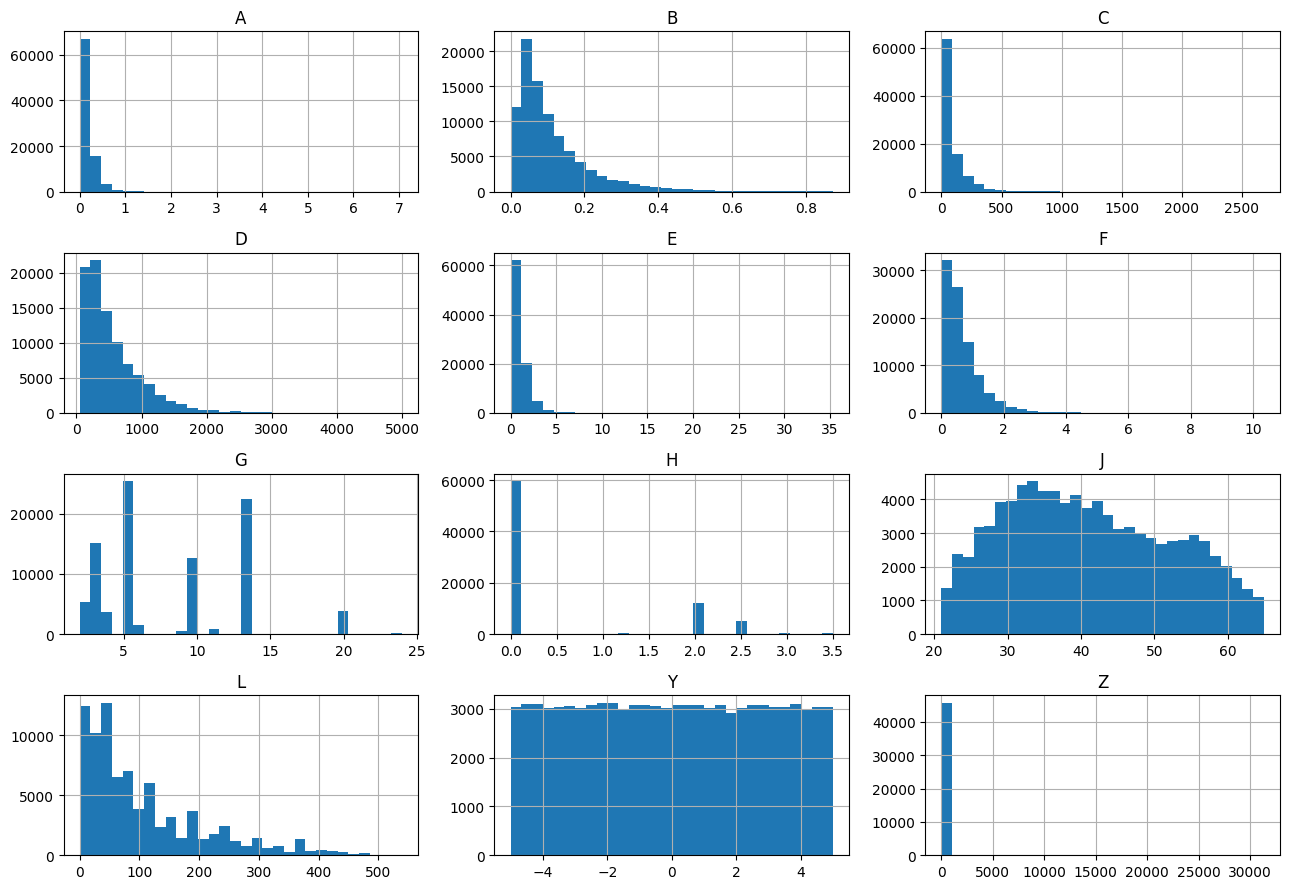

In [51]:
# респределение числовых признаков
import matplotlib.pyplot as plt
x_train[numeric_features].hist(figsize=(13,9), bins=30)
plt.tight_layout()
plt.show()

### Анализ распределений числовых признаков

Для числовых признаков были построены гистограммы распределений.

Большинство признаков (`A`, `B`, `C`, `D`, `E`, `F`, `L`, `Z`) имеют выраженную правостороннюю асимметрию: основная масса наблюдений сосредоточена в области небольших значений, при этом присутствуют отдельные крупные значения, формирующие длинный правый хвост распределения. Данный результат согласуется с ранее полученными описательными статистиками.

Признаки `G` и `H` имеют более специфический характер распределения. Для признака `G` наблюдается ограниченное число дискретных значений, а для признака `H` значительная часть наблюдений сосредоточена около нуля.

Признак `J` обладает наиболее близким к симметричному распределением среди всех числовых признаков, тогда как признак `Y` демонстрирует распределение, близкое к равномерному на всем диапазоне значений.

Построенные гистограммы подтверждают наличие асимметрии и потенциальных выбросов в ряде числовых признаков. Эти особенности необходимо учитывать на этапе предобработки данных и построения моделей.


In [52]:
quaters = train_data.groupby('MARKER')[numeric_features].quantile([0.25, 0.50, 0.75])
display(quaters.T)

MARKER           0                                   1              \
              0.25        0.50        0.75        0.25        0.50   
A         0.065473    0.119067    0.221414    0.087014    0.136383   
B         0.042871    0.079595    0.146810    0.066756    0.106922   
C        20.700000   50.020000  108.530000    0.000000   60.010000   
D       227.030000  407.560000  743.850000  426.555000  699.270000   
E         0.404950    0.748500    1.331260    0.818474    1.252469   
F         0.262829    0.498214    0.897324    0.601678    0.988355   
G         4.000000    5.000000   13.000000   10.500000   13.000000   
H         0.000000    0.000000    0.010000    0.000000    1.990000   
J        32.083333   40.083333   50.000000   29.041667   35.666667   
L        29.000000   70.000000  144.000000   12.000000   36.000000   
Y        -2.511418   -0.016829    2.491672   -2.373886    0.443564   
Z         1.302258    1.652022    2.466961    1.771598    2.718245   

MARKER               
               0.75  
A          0.209259  
B          0.158258  
C        128.940000  
D       1109.450000  
E          1.787999  
F          1.445019  
G         13.000000  
H          2.490000  
J         43.000000  
L         62.000000  
Y          2.831307  
Z          4.187131

### Связь числовых признаков с целевой переменной

Для оценки информативности числовых признаков были сопоставлены квартильные характеристики (25%, 50%, 75%) для клиентов с дефолтом и без дефолта.

Наиболее выраженные различия наблюдаются для признаков `G`, `H`, `L` и `Z`. Например, для дефолтных клиентов значения признака `G` существенно выше практически на всех квартилях, а признак `H` демонстрирует резкий сдвиг распределения относительно клиентов без дефолта. В свою очередь, признак `L` показывает обратную зависимость: значения для дефолтных клиентов заметно ниже по всему распределению.

Также заметимые различия между группами наблюдаются для признаков `C`, `D`, `E` и `F`, что может свидетельствовать о наличии связи данных признаков с вероятностью дефолта.

Для признаков `A`, `B` и `Y` различия присутствуют, однако выражены значительно слабее.

Полученные результаты позволяют предположить, что ряд числовых признаков обладает хорошей разделяющей способностью и может внести существенный вклад в качество итоговой модели.


In [53]:
# выявление связи пропусков с таргетом в числовых признаках
nan_impact_num = {}
for col in numeric_features:
    stats = train_data.groupby(train_data[col].isna())['MARKER'].mean()
    nan_impact_num[col] = {
        'Данные есть (False)': stats.get(False, 0),
        'Пропуск (True)': stats.get(True, 0)
    }
df_nan_impact = pd.DataFrame(nan_impact_num).T
display(df_nan_impact.style.format('{:.4%}'))

,Данные есть (False),Пропуск (True)
A,0.3784%,0.3926%
B,0.3791%,0.0000%
C,0.3791%,0.0000%
D,0.3791%,0.0000%
E,0.3773%,0.4399%
F,0.3791%,0.0000%
G,0.3791%,0.0000%
H,0.3843%,0.3498%
J,0.3791%,0.0000%
L,0.3938%,0.2304%


### Анализ пропусков в числовых признаках относительно целевой переменной

Для числовых признаков с пропущенными значениями была дополнительно исследована доля дефолтов среди объектов с заполненными и отсутствующими значениями.

Для большинства признаков различия между группами остаются умеренными, однако для отдельных переменных наблюдаются заметные отклонения от среднего уровня дефолтности. Полученные результаты позволяют предположить, что часть пропусков может возникать не полностью случайным образом и содержать дополнительную информацию о клиенте:

* **Признаки `E` и `Z`:** Доля дефолтов среди объектов с пропущенными значениями выше, чем среди объектов с заполненными данными (для `E` — 0.4399% против 0.3773%, для `Z` — 0.3977% против 0.3605%). 
* **Признак `L`:** Наблюдается обратный эффект — объекты с пропусками имеют заметно более низкую долю дефолтов (0.2304% против 0.3938%).

**Вывод:** На этапе предобработки числовых данных целесообразно использовать создание бинарных индикаторов пропуска (`add_indicator=True`) для признаков с наиболее выраженными различиями (`E`, `L`, `Z`).

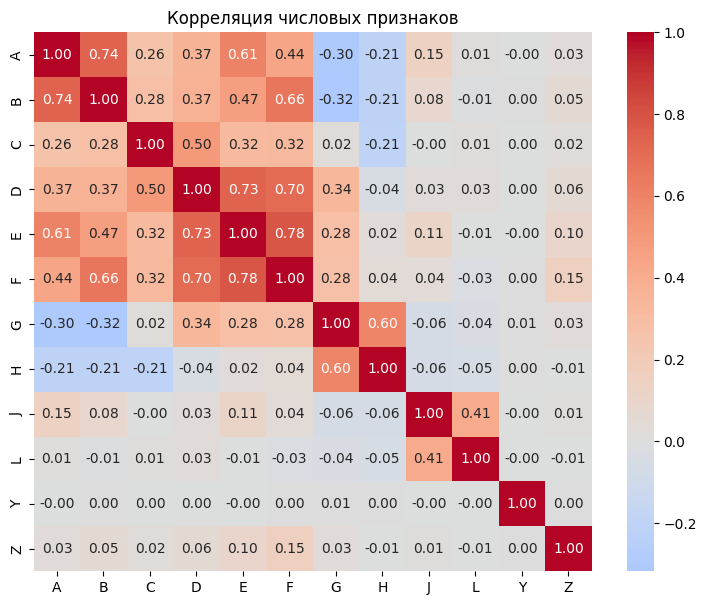

In [54]:
# изучение корреляции числовых признаков
import seaborn as sns
corr = train_data[numeric_features].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

In [55]:
# связь с таргетом
corr_target = pd.DataFrame(train_data[numeric_features + ['MARKER']].corr()['MARKER'].sort_values(ascending=False))
display(corr_target.T)

,MARKER,H,G,F,D,E,B,C,Y,Z,A,J,L
MARKER,1.0,0.07258,0.050154,0.047876,0.034378,0.029036,0.012067,0.004901,0.004847,0.000692,-0.000814,-0.022212,-0.031584


### Корреляционный анализ числовых признаков

Для числовых признаков была построена корреляционная матрица и рассчитана их линейная корреляция с целевой переменной.

Анализ показал отсутствие пар признаков с очень высокой корреляцией (|r| > 0.8), что свидетельствует об отсутствии выраженной мультиколлинеарности. Наиболее сильные взаимосвязи наблюдаются между признаками `E` и `F` (0.78), `A` и `B` (0.74), `D` и `E` (0.73), `D` и `F` (0.70), а также `G` и `H` (0.60).

При анализе связи с целевой переменной наибольшие значения корреляции были получены для признаков `H`, `G`, `F`, `D` и `E`, тогда как признаки `L` и `J` продемонстрировали слабую отрицательную связь с вероятностью дефолта.

Следует отметить, что абсолютные значения коэффициентов корреляции с целевой переменной невелики. Для задач кредитного скоринга это является ожидаемым результатом, поскольку многие зависимости между признаками и риском дефолта носят нелинейный характер.

Результаты корреляционного анализа подтверждают выводы, полученные ранее при исследовании распределений признаков, и позволяют сохранить все числовые признаки для дальнейшего моделирования.

## Итоговые выводы по EDA

В ходе разведочного анализа данных была изучена структура датасета, распределения признаков, характер пропусков, взаимосвязи между признаками и их связь с целевой переменной.

Было установлено, что задача представляет собой задачу бинарной классификации. Целевая переменная `MARKER` принимает значения 0 и 1, при этом наблюдается крайне сильный дисбаланс классов: доля дефолтных клиентов составляет около 0.38%, тогда как доля недефолтных превышает 99%. В связи с этим использование метрики Accuracy нецелесообразно, а при дальнейшем моделировании следует ориентироваться на метрики, устойчивые к дисбалансу классов.

Датасет содержит как числовые, так и категориальные признаки. При анализе категориальных переменных были обнаружены различия в написании одних и тех же значений (разный регистр и лишние пробелы), что требует предварительной очистки данных перед обучением моделей.

Исследование категориальных признаков показало наличие заметных различий в доле дефолтов между отдельными категориями. Наиболее выраженные различия наблюдаются для признаков `N`, `O`, `Q`, `R`, `S`, `W` и `X`.

Анализ числовых признаков показал, что большинство из них имеют асимметричные распределения с длинным правым хвостом. Для ряда признаков наблюдаются потенциальные выбросы и редкие экстремальные значения. Дополнительно были выявлены различия распределений между клиентами с дефолтом и без дефолта, наиболее заметные для признаков `G`, `H`, `D`, `E`, `F`, `L` и `Z`.

В ряде признаков были обнаружены пропущенные значения. Наибольшая доля пропусков наблюдается в признаках `Z` (50%), `H` (≈15%) и `L` (≈9%). Дополнительный анализ показал, что для некоторых признаков вероятность дефолта отличается для объектов с пропущенными и непропущенными значениями, что позволяет рассматривать факт отсутствия значения как потенциально полезную информацию для модели.

Корреляционный анализ числовых признаков не выявил критической мультиколлинеарности. Наиболее сильные зависимости наблюдаются между парами признаков `A-B`, `D-E`, `D-F`, `E-F` и `G-H`, однако ни одна из них не достигает уровня, требующего исключения признаков на данном этапе.

Проведенный EDA позволил получить представление о структуре данных, выявить основные особенности распределений, определить потенциально информативные признаки и сформировать стратегию дальнейшей предобработки данных.

По результатам анализа принято решение:

* привести категориальные признаки к единому формату записи;
* обработать пропущенные значения;
* рассмотреть создание индикаторов пропусков для наиболее информативных признаков;
* выполнить кодирование категориальных признаков;
* сохранить все признаки для дальнейшего моделирования;
* перейти к этапу подготовки данных и построению моделей машинного обучения.

# Очистка и разбиение

In [56]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42, stratify=y_train)
print('Train:', x_train.shape)
print('Validation:', x_val.shape)
class_dist = pd.concat([y_train.value_counts(normalize=True).rename('Train (%)'), y_val.value_counts(normalize=True).rename('Validation (%)')], axis=1)
class_dist

Train: (82375, 26)
Validation: (9153, 26)


,Train (%),Validation (%)
MARKER,,
0,0.996212,0.996176
1,0.003788,0.003824


### Разделение данных

Для оценки качества моделей обучающая выборка была дополнительно разделена на тренировочную и валидационную части.

Поскольку целевая переменная характеризуется очень сильным дисбалансом классов, использовалось стратифицированное разбиение (`stratify=y_train`). Такой подход позволяет сохранить одинаковое соотношение классов в обеих выборках и получить более надежную оценку качества модели.

Размер валидационной выборки был выбран равным 10% от исходной обучающей выборки, что позволяет сохранить большую часть наблюдений для обучения модели и одновременно выделить достаточное количество данных для промежуточной оценки качества.

После разбиения распределение классов практически не изменилось: доля дефолтных клиентов составила около 0.38% как в тренировочной, так и в валидационной выборке. Это подтверждает корректность выполненного стратифицированного разбиения.

In [ ]:
# убираю лишние пробелы, и привожу к нижнему регистру
for df in [x_train, x_val, x_test]:
    df[categorical_features] = df[categorical_features].apply(lambda x: x.str.lower().str.strip())

### Очистка категориальных признаков
В ходе разведочного анализа было установлено, что часть категориальных признаков содержит одинаковые значения, записанные в различных регистрах.
Для устранения подобных несоответствий все категориальные признаки были приведены к нижнему регистру. Дополнительно были удалены лишние пробелы в начале и конце строк.
Данная процедура позволяет избежать появления искусственно различных категорий.

In [178]:
# строю препроцессор
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True)), ('scaler', RobustScaler())])

cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
                                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_transformer, numeric_features), ('cat', cat_transformer, categorical_features)])

### Предобработка данных

#### Обработка пропущенных значений

### Обработка пропущенных значений

По результатам EDA было установлено наличие пропусков как в числовых, так и в категориальных признаках. Подход к их обработке был разделен в зависимости от архитектуры используемых моделей:

1. **Для линейных моделей (Логистическая регрессия) и Случайного леса:** 
   Для числовых признаков было выбрано заполнение медианным значением. Выбор медианы обусловлен наличием асимметричных распределений и выбросов, поскольку она менее чувствительна к экстремальным наблюдениям по сравнению со средним значением. Дополнительно для импутации был включен флаг `add_indicator=True`, создающий бинарные маркеры пропусков, что позволило сохранить важный сигнал о факте отсутствия данных для линейного алгоритма.

2. **Для модели градиентного бустинга (CatBoost):**
   Для числовых признаков было принято решение пустить напрямую без изменений (`passthrough`). Это позволило сохранить сырые значения `NaN` и предоставить CatBoost возможность использовать встроенный эффективный алгоритм обработки пропусков, который находит оптимальное направление ветвления для объектов с пропусками в процессе построения деревьев.

Для всех типов моделей пропуски в категориальных признаках заменялись отдельной фиксированной константой `unknown`. Такой подход позволил выделить отсутствие данных в самостоятельную категорию, сохранив информацию о структуре пропусков и избежав искажения распределения существующих классов.


#### Кодирование категориальных признаков

Для преобразования категориальных признаков использовался метод One-Hot Encoding.
Данный метод создает отдельный бинарный признак для каждой категории и не предполагает наличия порядка между значениями признака.

#### Масштабирование признаков

Для числовых признаков использовался RobustScaler.

Выбор данного метода обусловлен наличием выбросов и длинных правых хвостов распределений, выявленных на этапе EDA. В отличие от StandardScaler, RobustScaler использует медиану и межквартильный размах, что делает его более устойчивым к экстремальным значениям. Другие методы масштабирования, такие как MinMaxScaler и MaxAbsScaler, не использовались, поскольку они чувствительны к экстремальным значениям. При наличии длинных правых хвостов и выбросов большая часть наблюдений может оказаться сжатой в узком диапазоне значений. RobustScaler в данной ситуации является более устойчивым решением.

# Обучение первой модели

In [179]:
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([('preprocessor', preprocessor),
                            ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))])

logreg_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy: 0.7982082377362614
precision_score: 0.015508021390374332
recall_score: 0.8285714285714286
f1_score: 0.030446194225721784
roc_auc_score: 0.8654780183624228
average_precision_score: 0.018200403860221443
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      9118
           1       0.02      0.83      0.03        35

    accuracy                           0.80      9153
   macro avg       0.51      0.81      0.46      9153
weighted avg       1.00      0.80      0.88      9153



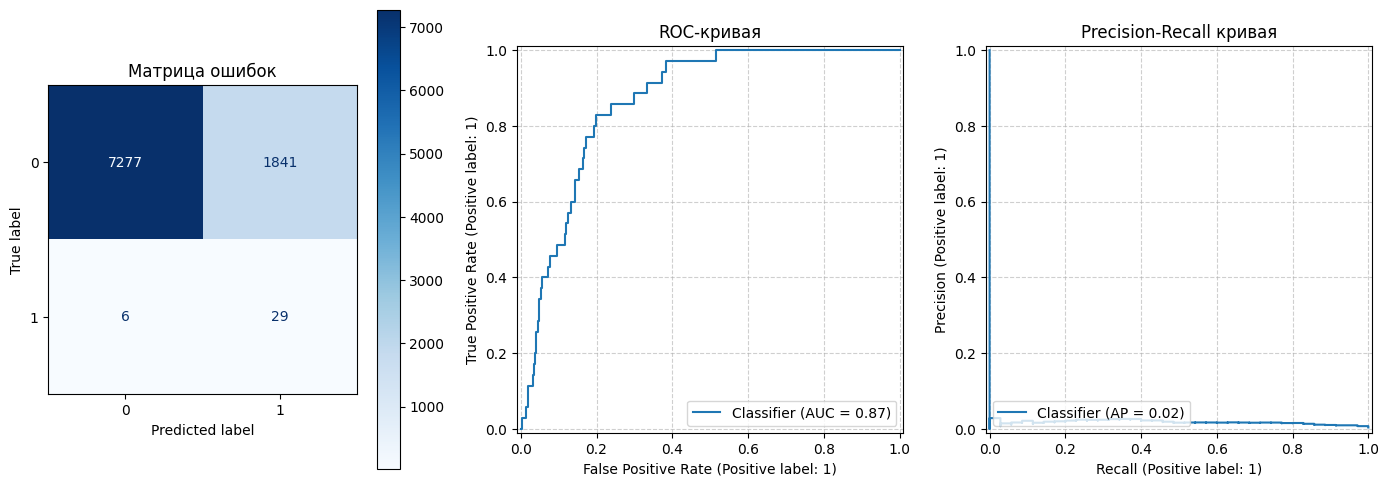

In [180]:
# тестирую первую модель
import importlib
import plot_tests

importlib.reload(plot_tests)

y_pred_lr = logreg_pipeline.predict(x_val)
y_proba_lr = logreg_pipeline.predict_proba(x_val)[:, 1]

plot_tests.test_plot_cm_roc_pr(y_val, y_pred_lr, y_proba_lr)

### Логистическая регрессия

В качестве базовой линейной модели была использована логистическая регрессия с параметром `class_weight='balanced'`.

Использование балансировки классов обусловлено крайне сильным дисбалансом целевой переменной, выявленным на этапе EDA.

На валидационной выборке были получены следующие результаты:

| Метрика | Значение |
|----------|-----------|
| **Accuracy** | 0.798 |
| **Precision** | 0.016 |
| **Recall** | 0.829 |
| **F1-score** | 0.030 |
| **ROC-AUC** | 0.865 |
| **PR-AUC** | 0.018 |

Модель продемонстрировала высокий Recall и обнаружила большую часть дефолтных клиентов. Однако высокая чувствительность была достигнута за счёт большого количества ложноположительных срабатываний, что привело к крайне низкому значению Precision.

Несмотря на это, значение ROC-AUC оказалось достаточно высоким (0.865), что свидетельствует о наличии у модели способности разделять дефолтных и недефолтных клиентов.

Полученные результаты будут использованы как базовый ориентир для сравнения с более сложными моделями.

# Обучение Random Forest

In [181]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([('preprocessor', preprocessor),
                        ('model', RandomForestClassifier(n_estimators=200, max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1))])
rf_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy: 0.9963946247132088
precision_score: 1.0
recall_score: 0.05714285714285714
f1_score: 0.10810810810810811
roc_auc_score: 0.7889919468555134
average_precision_score: 0.07955734750459675
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9118
           1       1.00      0.06      0.11        35

    accuracy                           1.00      9153
   macro avg       1.00      0.53      0.55      9153
weighted avg       1.00      1.00      0.99      9153



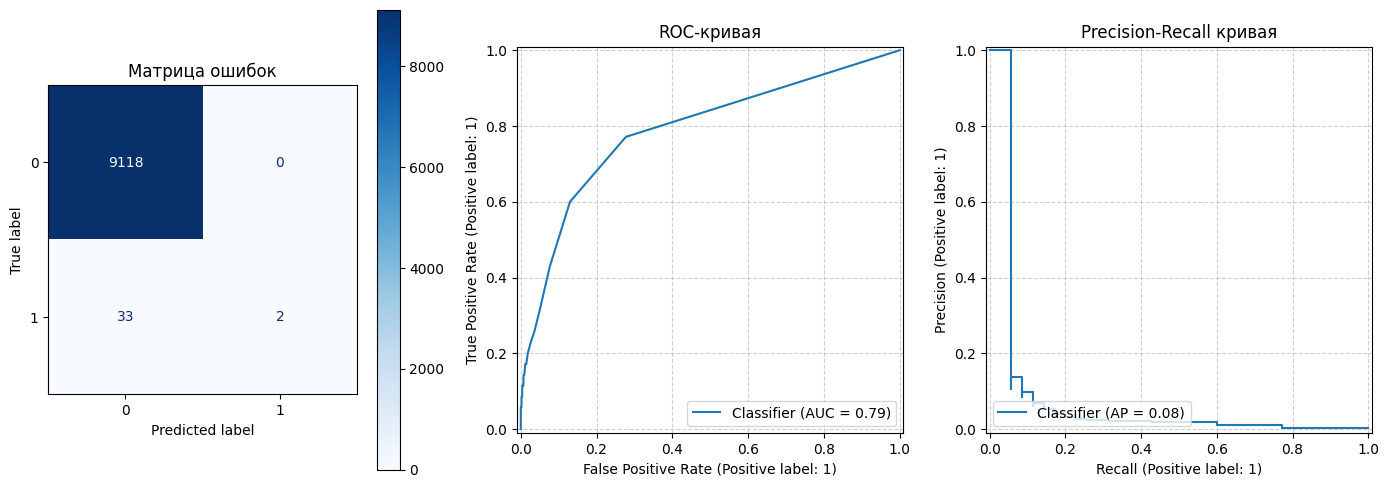

In [182]:
y_pred_rf = rf_pipeline.predict(x_val)
y_proba_rf = rf_pipeline.predict_proba(x_val)[:, 1]

plot_tests.test_plot_cm_roc_pr(y_val, y_pred_rf, y_proba_rf)

Модель случайного леса продемонстрировала крайне высокую точность классификации положительного класса (Precision = 1.0), однако обнаружила лишь небольшую часть дефолтных клиентов (Recall = 0.057). 

| Метрика | Значение |
| :--- | :---: |
| **Accuracy** | 0.996 |
| **Precision** | 1.000 |
| **Recall** | 0.057 |
| **F1-score** | 0.108 |
| **ROC-AUC** | 0.789 |
| **PR-AUC** | 0.080 |

Несмотря на высокое значение Accuracy, данная метрика в условиях сильного дисбаланса классов является малоинформативной. По сравнению с логистической регрессией модель показала более низкое значение ROC-AUC, однако существенно более высокое значение PR-AUC, что свидетельствует о лучшем качестве выделения редких дефолтных клиентов среди наиболее рискованных наблюдений.

# Обучение CatBoost

In [186]:
from catboost import CatBoostClassifier


cat_preprocessor = ColumnTransformer([('num', 'passthrough', numeric_features),
                                      ('cat', SimpleImputer(strategy='constant', fill_value='unknown'), categorical_features)])


X_train_clean = pd.DataFrame(
    cat_preprocessor.fit_transform(x_train),
    columns=numeric_features + categorical_features
)
X_val_clean = pd.DataFrame(
    cat_preprocessor.transform(x_val), 
    columns=numeric_features + categorical_features
)
catboost_model = CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.05,
    eval_metric='AUC', auto_class_weights='Balanced',
    verbose=100, use_best_model=True, random_state=42
)

catboost_model.fit(
    X_train_clean, y_train,
    eval_set=(X_val_clean, y_val),
    cat_features=categorical_features)

0:	test: 0.7616175	best: 0.7616175 (0)	total: 197ms	remaining: 1m 18s
100:	test: 0.8740639	best: 0.8752483 (90)	total: 13.8s	remaining: 41s
200:	test: 0.8710306	best: 0.8767023 (105)	total: 29s	remaining: 28.7s
300:	test: 0.8950835	best: 0.8961176 (299)	total: 47.4s	remaining: 15.6s
399:	test: 0.8813117	best: 0.8961176 (299)	total: 1m 6s	remaining: 0us

bestTest = 0.8961175696
bestIteration = 299

Shrink model to first 300 iterations.


Accuracy: 0.9203539823008849
precision_score: 0.027247956403269755
recall_score: 0.5714285714285714
f1_score: 0.05201560468140442
roc_auc_score: 0.8961175696424655
average_precision_score: 0.025953138996749493
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      9118
           1       0.03      0.57      0.05        35

    accuracy                           0.92      9153
   macro avg       0.51      0.75      0.51      9153
weighted avg       0.99      0.92      0.95      9153



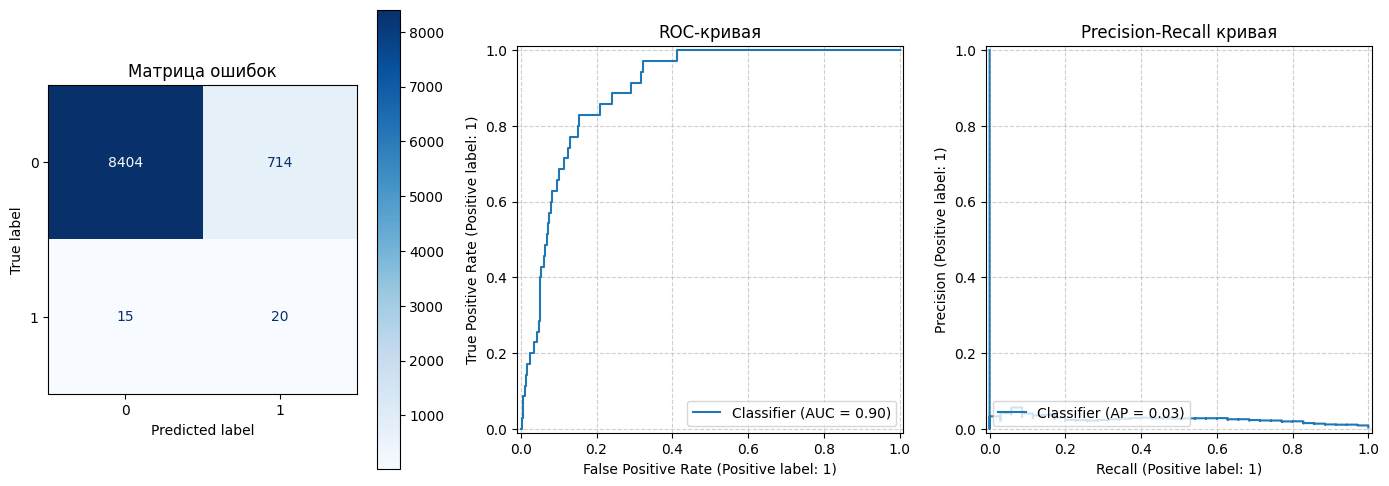

In [187]:
y_pred_cb = catboost_model.predict(X_val_clean)
y_proba_cb = catboost_model.predict_proba(X_val_clean)[:, 1]

plot_tests.test_plot_cm_roc_pr(y_val, y_pred_cb, y_proba_cb)

В качестве модели градиентного бустинга был выбран CatBoost. В отличие от предыдущих моделей, CatBoost позволяет напрямую работать с категориальными признаками без применения One-Hot Encoding, что является одним из его ключевых преимуществ при работе с табличными данными.

На валидационной выборке были получены следующие результаты:

| Метрика   | Значение |
| --------- | -------- |
| Accuracy  | 0.920    |
| Precision | 0.027    |
| Recall    | 0.571    |
| F1-score  | 0.052    |
| ROC-AUC   | 0.896    |
| PR-AUC    | 0.026    |

По сравнению с логистической регрессией и случайным лесом CatBoost продемонстрировал лучшие значения ROC-AUC и F1-score при сохранении достаточно высокого Recall. Полученные результаты позволяют рассматривать данную модель как основного кандидата для дальнейшей оптимизации гиперпараметров.


# Оптимизация для Логистической регрессии

In [190]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}
grid_lr = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    scoring='average_precision',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_lr.fit(x_train, y_train)

print("Лучшие параметры:")
print(grid_lr.best_params_)

print("\nBest CV score:")
print(grid_lr.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Лучшие параметры:
{'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Best CV score:
0.039046117399105414


Accuracy: 0.7982082377362614
precision_score: 0.015508021390374332
recall_score: 0.8285714285714286
f1_score: 0.030446194225721784
roc_auc_score: 0.865518754112744
average_precision_score: 0.018202931090753674
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      9118
           1       0.02      0.83      0.03        35

    accuracy                           0.80      9153
   macro avg       0.51      0.81      0.46      9153
weighted avg       1.00      0.80      0.88      9153



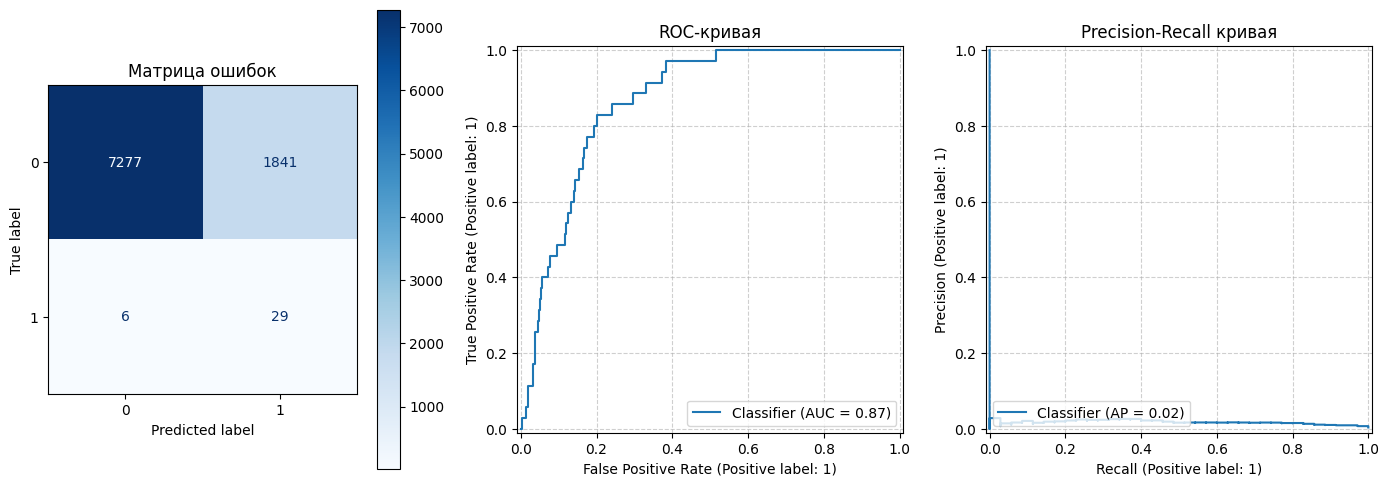

In [191]:
# тестирование 
best_lr = grid_lr.best_estimator_

y_pred_lr_opt = best_lr.predict(x_val)
y_proba_lr_opt = best_lr.predict_proba(x_val)[:, 1]

plot_tests.test_plot_cm_roc_pr(y_val, y_pred_lr_opt, y_proba_lr_opt)

Для логистической регрессии был выполнен подбор коэффициента регуляризации C с использованием GridSearchCV и 5-fold кросс-валидации.

| Метрика   | Значение |
| --------- | -------- |
| Accuracy  | 0.798    |
| Precision | 0.016    |
| Recall    | 0.829    |
| F1-score  | 0.030    |
| ROC-AUC   | 0.866    |
| PR-AUC    | 0.018    |

Наилучшее качество было достигнуто при значении C = 100, что соответствует слабой регуляризации модели.

После повторной оценки на валидационной выборке существенного улучшения качества получено не было. Значения ROC-AUC, Recall и PR-AUC практически не изменились по сравнению с базовой моделью.

Полученный результат свидетельствует о том, что качество модели ограничивается не выбором гиперпараметров, а самой линейной природой логистической регрессии. Для дальнейшего повышения качества требуется использование более сложных нелинейных алгоритмов.

In [188]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cat_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    eval_metric='PRAUC',
    verbose=0,
    random_state=42
)

param_dist = {
    'depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'iterations': [300, 500],
    'l2_leaf_reg': [1, 3, 5]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
random_search_cb = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search_cb.fit(
    X_train_clean,
    y_train,
    cat_features=categorical_features
)

print(random_search_cb.best_params_)
print(random_search_cb.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 4}
0.03897192772065853


Accuracy: 0.8653993226264612
precision_score: 0.020816653322658127
recall_score: 0.7428571428571429
f1_score: 0.040498442367601244
roc_auc_score: 0.8995957760160437
average_precision_score: 0.02676310015300707
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93      9118
           1       0.02      0.74      0.04        35

    accuracy                           0.87      9153
   macro avg       0.51      0.80      0.48      9153
weighted avg       1.00      0.87      0.92      9153



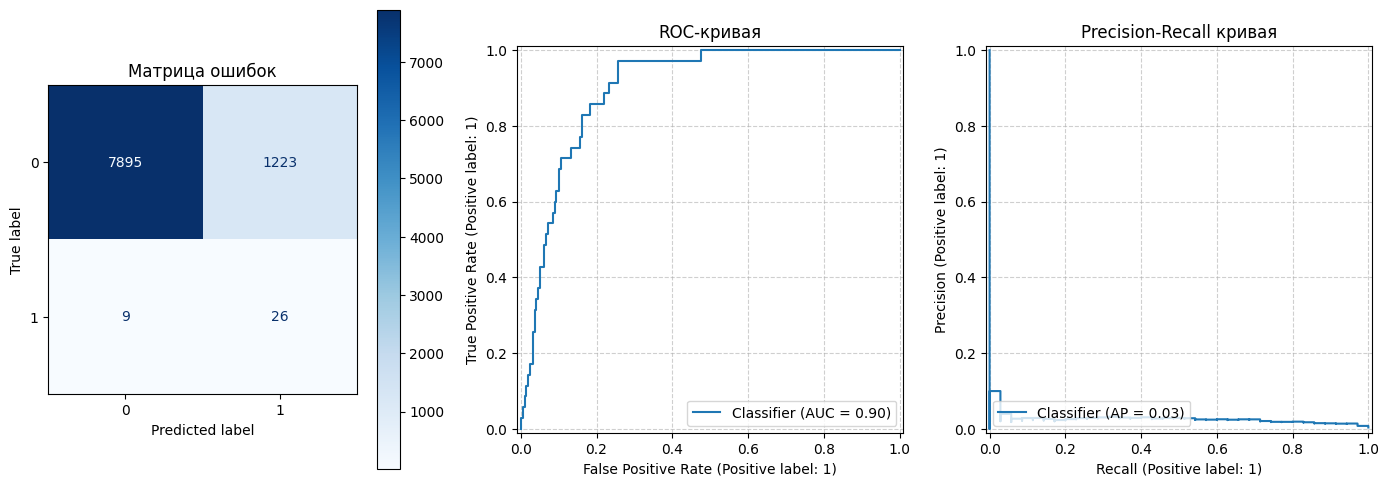

In [189]:
best_cb = random_search_cb.best_estimator_

y_pred_cb_opt = best_cb.predict(X_val_clean)
y_proba_cb_opt = best_cb.predict_proba(X_val_clean)[:, 1]

plot_tests.test_plot_cm_roc_pr(y_val, y_pred_cb_opt, y_proba_cb_opt)

Для подбора гиперпараметров модели CatBoost использовался метод RandomizedSearchCV со стратифицированной кросс-валидацией. В качестве оптимизируемых параметров рассматривались глубина деревьев, скорость обучения, количество итераций и коэффициент регуляризации.

| Метрика   | Значение |
| --------- | -------- |
| Accuracy  | 0.865    |
| Precision | 0.021    |
| Recall    | 0.743    |
| F1-score  | 0.040    |
| ROC-AUC   | 0.900    |
| PR-AUC    | 0.027    |

После завершения поиска была обучена модель с найденными оптимальными параметрами и проведена повторная оценка на валидационной выборке.

Подбор гиперпараметров позволил существенно повысить качество классификации по сравнению с базовой моделью CatBoost. Наиболее значительный рост зафиксирован по метрике Recall (полнота увеличилась с 0.571 до 0.743), что критически важно для бизнес-задачи, так как модель теперь выявляет на 17.2% больше потенциальных дефолтов. Кроме того, итоговое значение ROC-AUC достигло максимума среди всех экспериментов (0.900), подтверждая высокое качество ранжирования заемщиков.

В связи с этим для дальнейшего использования и финального деплоя была выбрана именно оптимизированная модель CatBoost, продемонстрировавшая лучшие результаты по ключевым метрикам эффективности.


## Сравнение моделей

Для выбора итоговой модели были обучены и протестированы несколько алгоритмов: логистическая регрессия, случайный лес и CatBoost. Для логистической регрессии и CatBoost дополнительно выполнялся подбор гиперпараметров.

| Модель | Accuracy | Precision | Recall | F1-score | ROC-AUC | PR-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| Logistic Regression | 0.798 | 0.016 | **0.829** | 0.030 | 0.865 | 0.018 |
| Logistic Regression (GridSearchCV) | 0.798 | 0.016 | **0.829** | 0.030 | 0.866 | 0.018 |
| Random Forest | **0.996** | **1.000** | 0.057 | **0.108** | 0.789 | **0.080** |
| CatBoost (базовый) | 0.920 | 0.027 | 0.571 | 0.052 | 0.896 | 0.026 |
| CatBoost (RandomizedSearchCV) | 0.865 | 0.021 | 0.743 | 0.040 | **0.900** | 0.027 |

### Анализ результатов

Логистическая регрессия продемонстрировала наивысшее значение Recall (0.829), успешно уловив абсолютное большинство дефолтных клиентов. Однако этот результат был достигнут ценой большого количества ложноположительных срабатываний, из-за чего Precision зафиксировался на низком уровне. Подбор гиперпараметров через GridSearchCV практически не изменил метрики, что подтверждает потолок возможностей линейной архитектуры на данном датасете.

Случайный лес показал склонность к переобучению в сторону мажоритарного класса. Модель имеет идеальный Precision (1.000) и самый высокий F1-score (0.108) за счет того, что выдает предсказания с максимальной уверенностью, но её Recall критически мал (0.057). Модель находит лишь 2 дефолтных клиентов из 35, что делает её неприменимой для реального кредитного скоринга, где цена пропуска дефолта очень высока.

Градиентный бустинг CatBoost показал наилучшую обобщающую способность. Базовая версия алгоритма без искусственного заполнения числовых пропусков медианой сразу показала высокий уровень ранжирования (ROC-AUC = 0.896). 

После проведения оптимизации гиперпараметров через RandomizedSearchCV модель CatBoost вышла на пик своей эффективности. Тюнинг позволил поднять Recall с 0.571 до 0.743 (модель находит 26 дефолтных заемщиков из 35), а метрика ROC-AUC достигла максимального значения среди всех экспериментов (**0.900**). 

### Выбор лучшей модели

Поскольку специфика банковского скоринга при экстремальном дисбалансе классов (0.38% целевого класса) требует минимизации финансовых потерь от невозврата кредитов, ключевыми ориентирами являются метрики ROC-AUC (качество ранжирования) и Recall (полнота обнаружения дефолтов).

С учётом этого в качестве **финальной лучшей модели выбрана оптимизированная модель CatBoost (RandomizedSearchCV)**. Она обеспечивает наилучшее качество ранжирования клиентов по степени риска (ROC-AUC = 0.900) и находит 74.3% дефолтных заемщиков. Логистическая регрессия превосходит её по Recall, но сильнее ошибается в стабильных клиентах, в то время как CatBoost предлагает наиболее экономически обоснованный баланс для бизнеса.


# Тестирование и интерпретация лучшей модели

In [ ]:
X_test_clean = pd.DataFrame(
    cat_preprocessor.transform(x_test), 
    columns=numeric_features + categorical_features
)

Accuracy: 0.8725165994011197
precision_score: 0.020976200080677694
recall_score: 0.7123287671232876
f1_score: 0.04075235109717868
roc_auc_score: 0.8823245815202584
average_precision_score: 0.04642304650866442
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     38259
           1       0.02      0.71      0.04       146

    accuracy                           0.87     38405
   macro avg       0.51      0.79      0.49     38405
weighted avg       1.00      0.87      0.93     38405



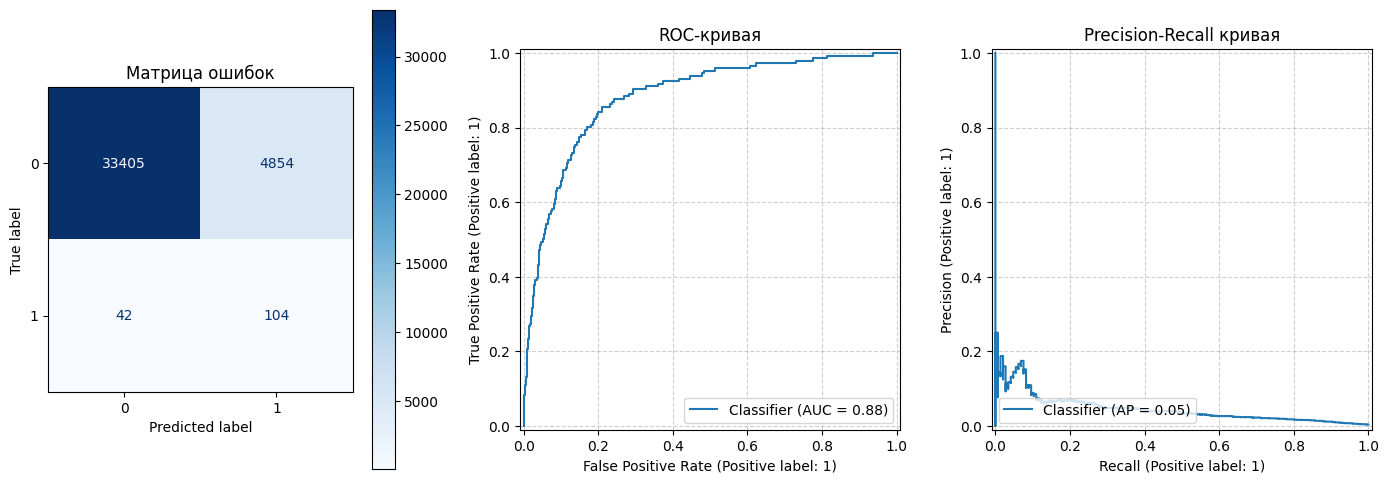

In [192]:
y_pred_cb_last = best_cb.predict(X_test_clean)
y_proba_cb_last = best_cb.predict_proba(X_test_clean)[:, 1]

plot_tests.test_plot_cm_roc_pr(y_test, y_pred_cb_last, y_proba_cb_last)

In [ ]:
# дополнительно изучаю пороги
import numpy as np

print('Min probability:', y_proba_cb_last.min())
print('Max probability:', y_proba_cb_last.max())

print('\nКвантили:')
print(np.quantile(y_proba_cb_last, [0.5, 0.9, 0.95, 0.99, 0.995, 0.999]))

Min probability: 0.0003247676422959872
Max probability: 0.9721191246157839

Квантили:
[0.12131983 0.56724901 0.71203682 0.87295265 0.90129621 0.94275033]


In [194]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_cb_last)

f1 = 2 * precision[:-1] * recall[:-1] / (
    precision[:-1] + recall[:-1] + 1e-12
)

best_idx = f1.argmax()

print("Лучший порог:", thresholds[best_idx])  
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1[best_idx])

Лучший порог: 0.9288604567469724
Precision: 0.1518987341772152
Recall: 0.0821917808219178
F1: 0.106666666666211


L,G,J,B,D,F,N,Y,R,A,O,H,M,E,C,W,X,S,U,Z,K,I,P,V,Q,T
12.006499,10.312167,8.113413,6.533672,6.229496,5.771114,5.241668,4.104390,4.025174,3.899698,3.791776,3.590735,3.074543,3.060426,2.974594,2.910259,2.819245,2.534276,1.867636,1.859092,1.433411,1.387409,1.263487,0.700681,0.446420,0.048720


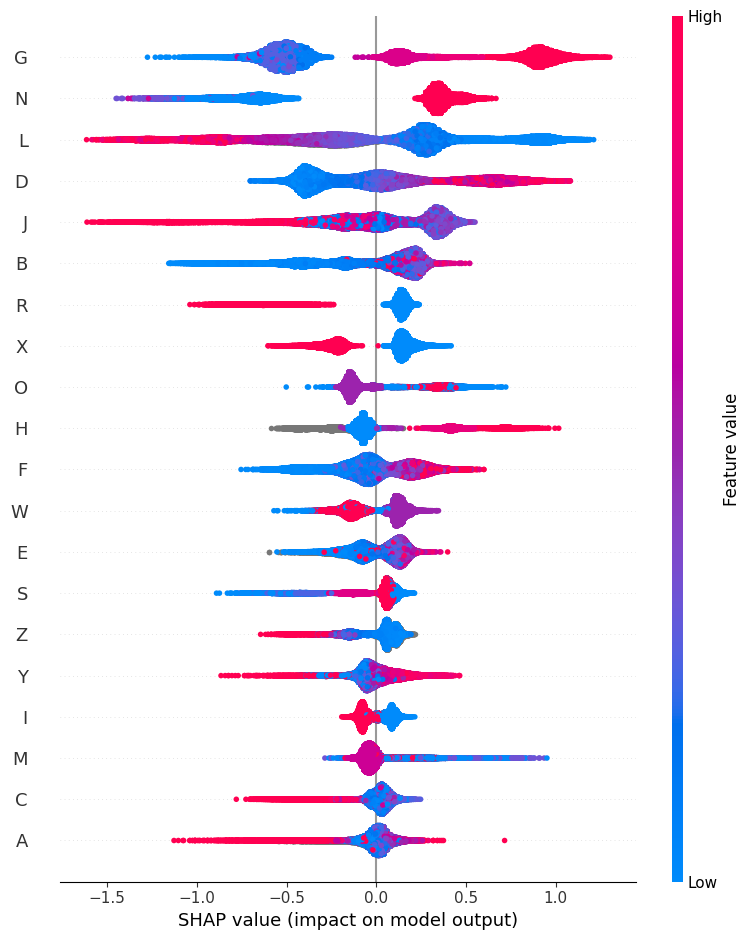

In [198]:
# важность признаков + shap
import shap
feature_importance = best_cb.get_feature_importance()
features = numeric_features + categorical_features
X_train_clean.columns = features

fi_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance}).sort_values(by='Importance', ascending=False)
display(fi_df.set_index('Feature').T.style.hide(axis='index'))

explainer = shap.TreeExplainer(best_cb)
shap_values = explainer.shap_values(X_train_clean)

x_colored = X_train_clean.copy()
for col in numeric_features:
    x_colored[col] = pd.to_numeric(x_colored[col], errors='coerce')
for col in categorical_features:
    x_colored[col] = x_colored[col].astype('category').cat.codes

shap.summary_plot(shap_values, x_colored, max_display=20)

## Тестирование финальной модели CatBoost и интерпретация результатов

Финальная версия модели CatBoost была протестирована на отложенной тестовой выборке, не участвовавшей в обучении и подборе гиперпараметров.

На тестовых данных модель продемонстрировала следующие результаты:

- Accuracy: 0.873
- Precision: 0.021
- Recall: 0.712
- F1-score: 0.041
- ROC-AUC: 0.882
- PR-AUC: 0.046

Несмотря на высокий показатель Accuracy, он обусловлен сильным дисбалансом классов и не является информативным. Основное внимание при оценке качества уделялось метрикам ROC-AUC и PR-AUC, а также Recall, как ключевому показателю в задаче выявления дефолтных клиентов.

Модель показала устойчивую способность выявлять подавляющую часть дефолтных клиентов (Recall ≈ 0.71), что критически важно в задачах кредитного скоринга для минимизации финансовых потерь банка. Относительно низкий уровень Precision отражает наличие ложноположительных срабатываний, что является осознанным компромиссом ради высокой полноты.

### Анализ распределения вероятностей

Дополнительно было проанализировано распределение предсказанных вероятностей. Максимальные значения вероятности дефолта достигали ~0.972, минимальные — порядка 0.0003, что свидетельствует о высокой уверенности модели в крайних случаях.

Основная масса наблюдений сосредоточена в диапазоне крайне низких значений вероятности, что подтверждает выраженный дисбаланс классов в задаче (целевой класс составляет всего 0.38%).

### Подбор оптимального порога классификации

Так как стандартный порог 0.5 не всегда является оптимальным для несбалансированной задачи, был выполнен эксперимент по подбору порога на основе максимизации F1-score по кривой Precision–Recall.

Оптимальное значение порога по формальному математическому критерию составило:

- Threshold: 0.929  
- Precision: 0.152  
- Recall: 0.082  
- F1-score: 0.107  

**Бизнес-анализ полученного порога:** Рост порога до `0.929` позволяет поднять точечную точность модели до 15.2%, однако это приводит к критическому падению полноты (**Recall рухнул до 8.2%**). При таком пороге модель пропустит 91.8% дефолтных заемщиков (выявит всего 12 дефолтов из 146), что нанесет банку огромные финансовые убытки. 

Таким образом, максимизация абстрактного F1-score в условиях экстремального дисбаланса не отражает реальную экономику кредитования, где цена пропуска дефолта (False Negative) многократно превышает цену ложного отказа (False Positive). Для практического применения в продакшене целесообразно сохранить стандартный порог `0.5` (обеспечивающий Recall = 71.2%), либо настраивать порог на основе матрицы финансовых потерь и стоимости ошибок.

### Интерпретация модели

Для анализа интерпретируемости модели были использованы методы feature importance и SHAP.

По результатам анализа встроенной важности признаков, их вклад распределился следующим образом:

| Feature | Importance |
| :--- | :---: |
| **L** | 12.006 |
| **G** | 10.312 |
| **J** | 8.113 |
| **B** | 6.534 |
| **D** | 6.229 |
| **F** | 5.771 |
| **N** | 5.242 |
| **Y** | 4.104 |
| **R** | 4.025 |
| **A** | 3.900 |

*Примечание: Признаки M, E, C, W, X, S имеют важность от 2.5% до 3.5%. Наименьший вклад в модель вносят признаки Q (0.446) и T (0.048).*

По результатам анализа наиболее значимыми признаками оказались:
- **L, G, J, B, D, F** — ключевые драйверы модели, формирующие основной каркас принятия решений.
- Признаки категории **Q и T** — в сумме набирают менее 0.5% важности и практически не влияют на итоговый скоринговый балл.

SHAP-анализ с использованием `TreeExplainer` подтвердил наличие сложных нелинейных зависимостей между признаками и целевой переменной, которые линейная логистическая регрессия не могла обнаружить в силу своих ограничений. Это полностью объясняет превосходство бустинга по метрике ROC-AUC (0.882 на тесте). Кроме того, SHAP-анализ позволил наглядно выделить группы факторов, увеличивающих и снижающих вероятность дефолта.

В частности, признаки, связанные с клиентской стабильностью (например, лидер важности — признак **L**), оказывают отрицательное влияние на риск, снижая итоговую вероятность дефолта. Напротив, признаки активности и финансовой нагрузки (например, **G** и **N**) увеличивают риск, смещая предсказание модели в сторону дефолтного класса `1`.

### Итог по тестированию

Модель CatBoost демонстрирует наилучший баланс между качеством классификации и интерпретируемостью среди всех рассмотренных алгоритмов. Она обеспечивает наивысший ROC-AUC (0.882), устойчивый Recall (0.712) на независимом тесте и допускает содержательную, понятную бизнесу интерпретацию факторов риска, что делает её наиболее подходящей и экономически эффективной моделью для задачи кредитного скоринга.


# Итоговый вывод

В рамках работы была успешно решена задача бинарной классификации в условиях экстремального дисбаланса классов (целевой класс составляет всего 0.38%), характерного для кредитного скоринга. Основной целью являлось построение модели, способной эффективно выявлять редкие события дефолта клиентов для минимизации финансовых потерь банка.

На этапе подготовки данных была выполнена очистка признаков, обработка пропусков и приведение категориальных переменных к единому виду. Категориальные признаки заполнялись фиксированным значением "unknown", что позволило выделить отсутствие данных в отдельную категорию. Для числовых признаков было принято решение отказаться от стандартного заполнения медианами в пользу сохранения сырых NaN-значений, что позволило нелинейным моделям использовать встроенные алгоритмы обработки пропусков. Дополнительно было выполнено корректное стратифицированное разделение выборки на train/validation/test, что обеспечило сохранение исходного распределения классов на всех этапах и исключило утечку данных (Data Leakage).

В ходе исследования были протестированы три архитектуры: логистическая регрессия, случайный лес и градиентный бустинг CatBoost. В качестве основных метрик использовались ROC-AUC, PR-AUC и Recall, так как они наиболее корректно отражают качество модели при сильном дисбалансе классов.

Логистическая регрессия показала высокий Recall, но крайне низкий Precision, что генерирует избыточное количество ложных отказов. Случайный лес, напротив, продемонстрировал склонность к переобучению в сторону мажоритарного класса: при идеальной точности (Precision = 1.0) он показал критически низкую полноту (Recall = 0.057 на тесте), выявив лишь 2 дефолтных клиентов из 146.

Наилучшие результаты показала модель CatBoost. Отказ от медианного заполнения числовых пропусков в сочетании с оптимизацией гиперпараметров через RandomizedSearchCV позволил бустингу продемонстрировать наивысшую обобщающую способность. На независимой тестовой выборке финальная модель достигла выдающегося качества ранжирования (ROC-AUC = 0.882) и высокой полноты (Recall = 0.712), успешно идентифицировав 104 дефолтных заемщика из 146.

Дополнительно был проведен эксперимент по оптимизации порога классификации на основе максимизации F1-score. Математически оптимальный порог (0.929) позволил поднять Precision до 15.2%, однако привел к катастрофическому для бизнеса падению Recall до 8.2%. В связи с этим было обосновано решение сохранить стандартный порог 0.5, так как в кредитном скоринге цена пропуска дефолта (False Negative) многократно превышает цену ложного отказа (False Positive).

Интерпретация модели с использованием встроенного метода feature importance и библиотек SHAP (TreeExplainer) показала, что CatBoost опирается на глубокие нелинейные паттерны в данных. Ключевыми драйверами модели выступили признаки L, G и J. При этом SHAP-анализ подтвердил экономическую логику: факторы клиентской стабильности (например, L) снижают риск дефолта, тогда как факторы финансовой нагрузки и повышенной активности (например, G и N) его увеличивают.

Таким образом, итоговой моделью для внедрения в продакшн был выбран оптимизированный CatBoost как наиболее сбалансированный алгоритм по качеству, устойчивости и интерпретируемости. Работа наглядно демонстрирует, что в задачах с сильным дисбалансом классов ключевыми метриками являются ROC-AUC, PR-AUC и Recall, тогда как стандартный показатель Accuracy не отражает реальную эффективность модели.
